<a href="https://colab.research.google.com/github/Vedanshdhingra/Customer-segmentation-and-churn-prediction/blob/main/Customer_segmentation_and_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# project name: customer churn production and segmentation

In [ ]:
!unzip -o archive.zip




Archive:  archive.zip
  inflating: Telco_customer_churn.xlsx  


In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")


In [ ]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


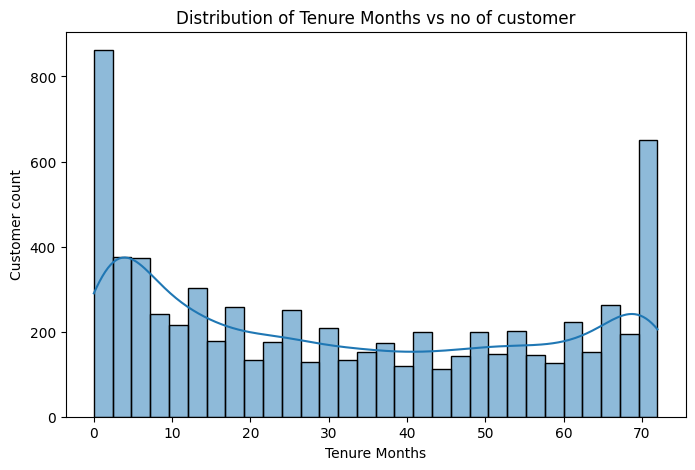

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Tenure Months"], bins=30 , kde = True)
plt.xlabel("Tenure Months")
plt.ylabel("Customer count")
plt.title("Distribution of Tenure Months vs no of customer")
plt.show()

In [ ]:
df["Tenure Months"].max()


72

In [ ]:
df["Tenure Months"].min()

0

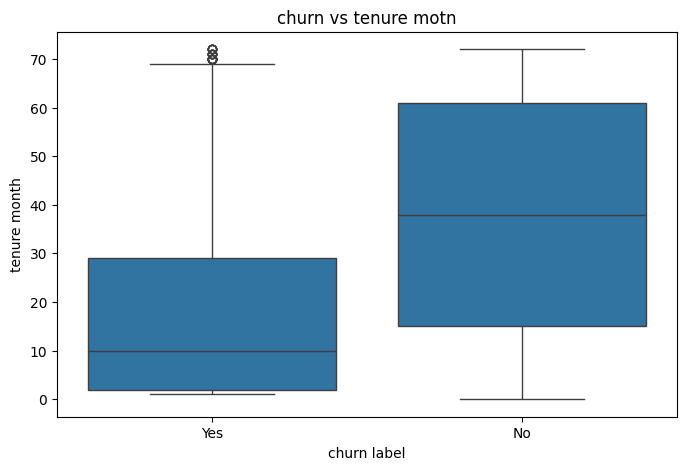

In [ ]:
 plt.figure(figsize=(8,5))

sns.boxplot(x='Churn Label', y='Tenure Months', data=df)

plt.xlabel('churn label')

plt.ylabel('tenure month')

plt.title('churn vs tenure motn')

plt.show()

In [ ]:
df["Churn Label"].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df["Churn Label"] == 'Yes'

,Churn Label
0,True
1,True
2,True
3,True
4,True
...,...
7038,False
7039,False
7040,False
7041,False


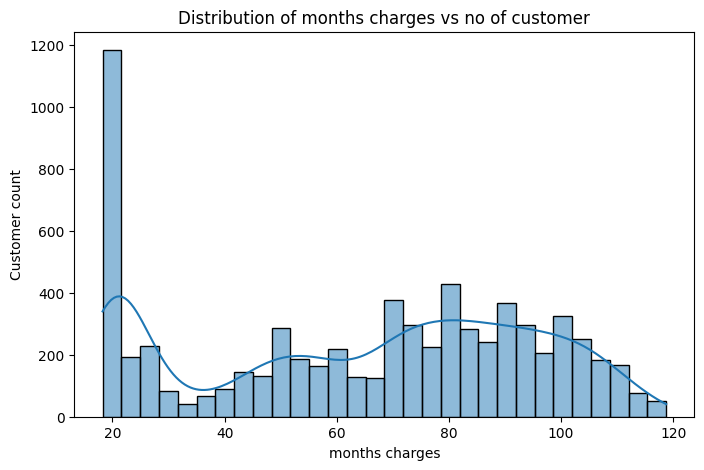

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Monthly Charges'],

bins=30, kde=True)

plt.xlabel('months charges')

plt.ylabel('Customer count')

plt.title('Distribution of months charges vs no of customer')

plt.show()


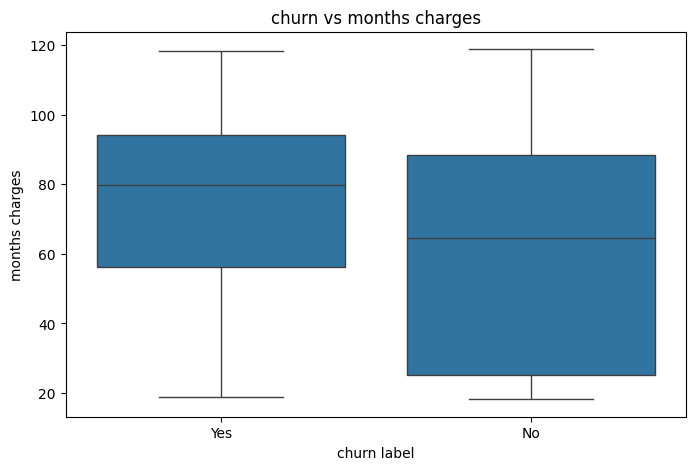

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges' , data=df)
plt.xlabel("churn label")
plt.ylabel('months charges')
plt.title('churn vs months charges')
plt.show()


In [ ]:
df['Monthly Charges'].quantile ([0.25,0.5,0.75])


,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df[df['Churn Label']=='Yes'] ['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No'] ['Monthly Charges'].quantile ([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


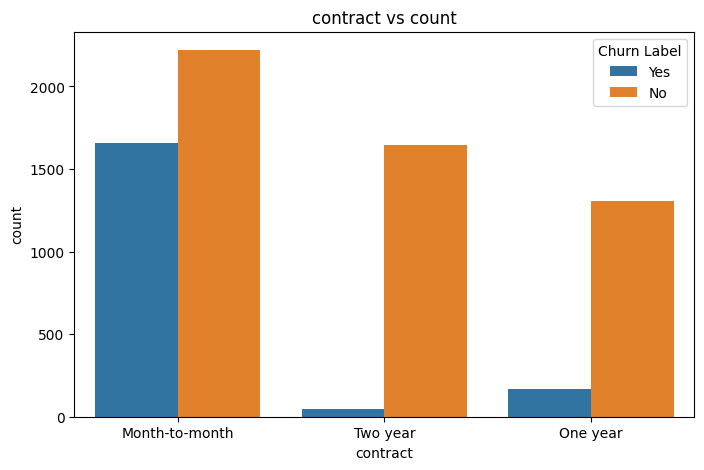

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract',

hue='Churn Label', data=df)

plt.xlabel('contract')

plt.ylabel('count')

plt.title('contract vs count')

plt.show()

In [ ]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

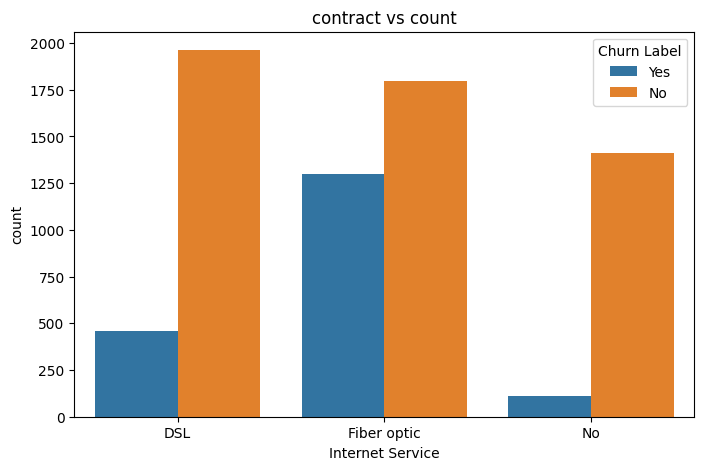

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Internet Service', hue='Churn Label', data=df)

plt.xlabel('Internet Service')

plt.ylabel('count')

plt.title('contract vs count')

plt.show()

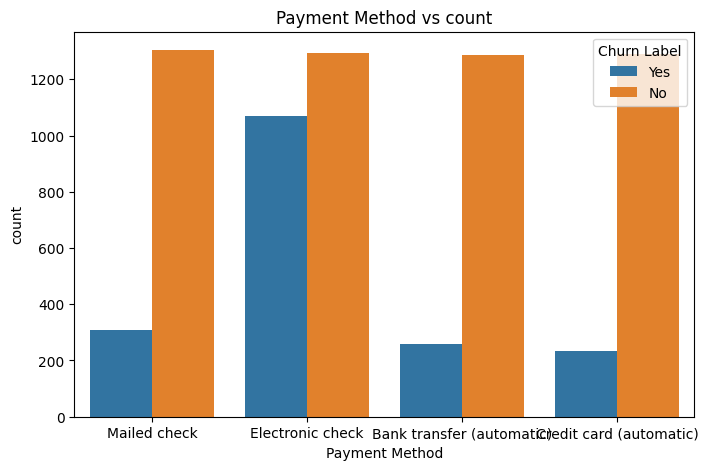

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Payment Method', hue='Churn Label', data=df)

plt.xlabel('Payment Method')

plt.ylabel('count')

plt.title('Payment Method vs count')

plt.show()

In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

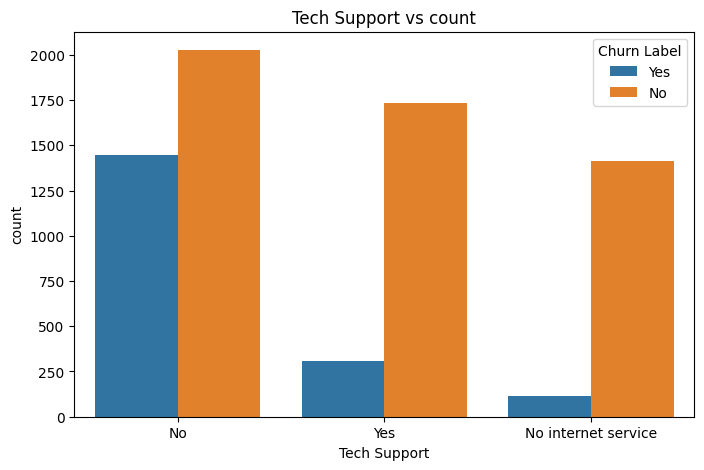

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Tech Support', hue='Churn Label', data=df)

plt.xlabel('Tech Support')

plt.ylabel('count')

plt.title('Tech Support vs count')

plt.show()

In [ ]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [ ]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
numerical_cols=['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

In [ ]:
correlation_matrix=df[numerical_cols].corr()

In [ ]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [ ]:
from matplotlib.colors import Normalize
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Tenure Months']==0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [ ]:
[7043-7032,(11/7043)]

[11, 0.001561834445548772]

In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
# drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label',
#               'Churn Score','CLTV','Churn Reason']

# df=df.drop(columns=drop_columns)
# List of columns to remove
drop_columns = [
    'CustomerID', 'Count', 'Country', 'State', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude', 'Churn Label',
    'Churn Score', 'CLTV', 'Churn Reason'
]

# Drop columns from the DataFrame
df = df.drop(columns=drop_columns, errors='ignore')

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [ ]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

In [ ]:
df=df.drop(columns='City')

In [ ]:
df_encode=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encode.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encode.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [ ]:
X=df_encode.drop(columns='Churn Value')
# drop('churn Value,axis=1)
y=df_encode['Churn Value']

In [ ]:
X.shape,y.shape

((7043, 30), (7043,))

In [ ]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [ ]:
# X.info()
(5174/7043)*100,(1869/7043)*100


(73.4630129206304, 26.536987079369588)

# machine learning implementation


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [ ]:
X_train.shape,X_test.shape ,y_train.shape,y_test.shape

((5634, 30), (1409, 30), (5634,), (1409,))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
rf_model.fit(X_train , y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=rf_model.predict(X_test)

In [ ]:
y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [ ]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(y_test, y_pred)
accuracy

0.7856635911994322

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)


In [ ]:
print(cm)

[[902 107]
 [195 205]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



# Approach 1 -Handle class imbalance

In [ ]:
rf_balanced=RandomForestClassifier( n_estimators=100,random_state=42,class_weight='balanced')

rf_balanced.fit(X_train,y_train)

y_pred_balanced=rf_balanced.predict( X_test)

accuracy_balanced=accuracy_score(y_test,y_pred_balanced)

cm_balanced=confusion_matrix(y_test,y_pred_balanced)

print(accuracy_balanced,cm_balanced)
print(classification_report(y_test, y_pred_balanced))

0.7920511000709723 [[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



# Approach 2 hyperparameter tuning

In [ ]:
rf_tuned=RandomForestClassifier( n_estimators=300,max_depth=10 ,random_state=42,class_weight='balanced')

rf_tuned.fit(X_train,y_train)

y_pred_tuned=rf_tuned.predict( X_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



# Approach 3 Feature importance  analysis

In [ ]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})
feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

                                   Feature  Importance
0                            Tenure Months    0.173457
1                          Monthly Charges    0.167753
2                            Total Charges    0.190197
3                              Gender_Male    0.027464
4                       Senior Citizen_Yes    0.020699
5                              Partner_Yes    0.025513
6                           Dependents_Yes    0.035459
7                        Phone Service_Yes    0.003962
8          Multiple Lines_No phone service    0.004442
9                       Multiple Lines_Yes    0.019881
10            Internet Service_Fiber optic    0.034156
11                     Internet Service_No    0.004397
12     Online Security_No internet service    0.007423
13                     Online Security_Yes    0.024319
14       Online Backup_No internet service    0.004423
15                       Online Backup_Yes    0.020817
16   Device Protection_No internet service    0.006419
17        

In [ ]:
print(feature_importance .tail(15))

                                   Feature  Importance
15                       Online Backup_Yes    0.020817
16   Device Protection_No internet service    0.006419
17                   Device Protection_Yes    0.018307
18        Tech Support_No internet service    0.005164
19                        Tech Support_Yes    0.022837
20        Streaming TV_No internet service    0.004983
21                        Streaming TV_Yes    0.017024
22    Streaming Movies_No internet service    0.004204
23                    Streaming Movies_Yes    0.017697
24                       Contract_One year    0.020746
25                       Contract_Two year    0.029158
26                   Paperless Billing_Yes    0.025163
27  Payment Method_Credit card (automatic)    0.012948
28         Payment Method_Electronic check    0.038823
29             Payment Method_Mailed check    0.012167


In [ ]:
X_selected = X.drop(['Phone Service_Yes' , 'Multiple Lines_No phone service'], axis=1)


In [ ]:
X_train_sel , X_test_sel , y_train_sel , y_test_sel = train_test_split(X_selected , y , test_size=0.20 , random_state=42)

In [ ]:
rf_selected=RandomForestClassifier( n_estimators=300,max_depth=10 ,random_state=42,class_weight='balanced')

rf_selected.fit(X_train_sel,y_train_sel)

y_pred_selected=rf_selected.predict( X_test_sel)

print(classification_report(y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



# approach ocombination of trees and depth

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Hyperparameters list setup
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]
results = []

# Hyperparameter grid search loop
for n_trees in n_estimators_list:
    for depth in max_depth_list:
        # Model initialization
        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        # Model training and prediction
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        # Metrics calculation
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Save results into a valid dictionary
        results.append({
            'Trees': n_trees,
            'Depth': depth,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1Score': f1
        })

# Create and sort DataFrame
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['Recall', 'Accuracy'], ascending=False)

# Display top 20 rows
print(result_df.head(20))


    Trees  Depth  Accuracy  Recall  Precision   F1Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')


In [ ]:
cv_accuracy=cross_val_score(final_rf,X,y, cv=5, scoring='accuracy')
cv_accuracy

array([0.76721079, 0.79772889, 0.76224273, 0.78551136, 0.78409091])

In [ ]:
cv_accuracy.mean()

np.float64(0.7793569343183432)

In [ ]:
cv_recall=cross_val_score(final_rf,X,y, cv=5, scoring='recall')
cv_recall

array([0.70855615, 0.76470588, 0.74064171, 0.74331551, 0.71045576])

In [ ]:
cv_recall.mean()

np.float64(0.7335350030823931)

# OPTIONAL

In [ ]:
from sklearn.metrics import roc_auc_score , roc_curve

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
y_prob1=rf_tuned.predict_proba(X_test)
churn_prob=y_prob1[:,1]

In [ ]:
y_prob=rf_tuned.predict_proba(X)
churn_probability=y_prob[:,1]

In [ ]:
fpr , tpr , threshold=roc_curve(y_test,churn_prob)
auc_score = roc_auc_score(y_test, churn_prob)
print("AUC Score:", auc_score)

AUC Score: 0.857104806739346


# Customer Segmentation

In [ ]:
segmentation_data = pd.DataFrame(
    {
        "Tenure Months": X["Tenure Months"],
        "Monthly Charges": X["Monthly Charges"],
        "Total Charges": X["Total Charges"],
        "Churn Probability": churn_probability,
    }
)


In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


# implementation of kmeans

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

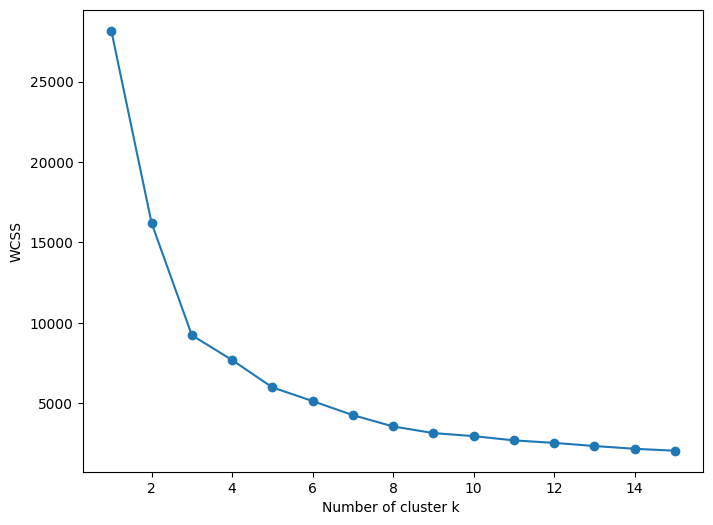

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42 )
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16), wcss, marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")

plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3 , random_state=42)

In [ ]:
clusters=kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


In [ ]:
segmentation_data['Cluster'] = clusters

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [ ]:
cluster_summary = segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [ ]:
cluster_names={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'Loyal Premium Costomers'

}

In [ ]:
segmentation_data['Cluster Segment']= segmentation_data['Cluster'].map(cluster_names)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,1,High Risk New Customers
1,2,70.70,151.65,0.796013,1,High Risk New Customers
2,8,99.65,820.50,0.805827,1,High Risk New Customers
3,28,104.80,3046.05,0.563031,1,High Risk New Customers
4,49,103.70,5036.30,0.517474,2,Loyal Premium Costomers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.082095,0,Budget Loyal Customers
7040,72,103.20,7362.90,0.049001,2,Loyal Premium Costomers
7041,11,29.60,346.45,0.302367,0,Budget Loyal Customers


In [ ]:
plt.figure(figsize=(10,8))


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Tenure Months', ylabel='Monthly Charges'>

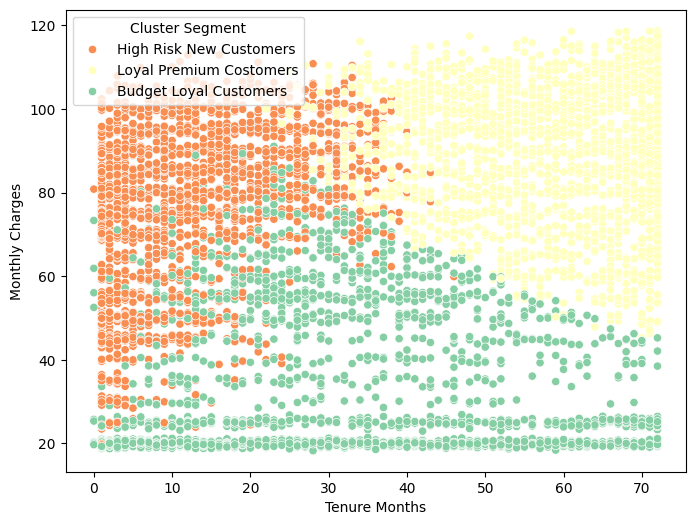

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months', y='Monthly Charges',hue='Cluster Segment', data=segmentation_data, palette='Spectral')


<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

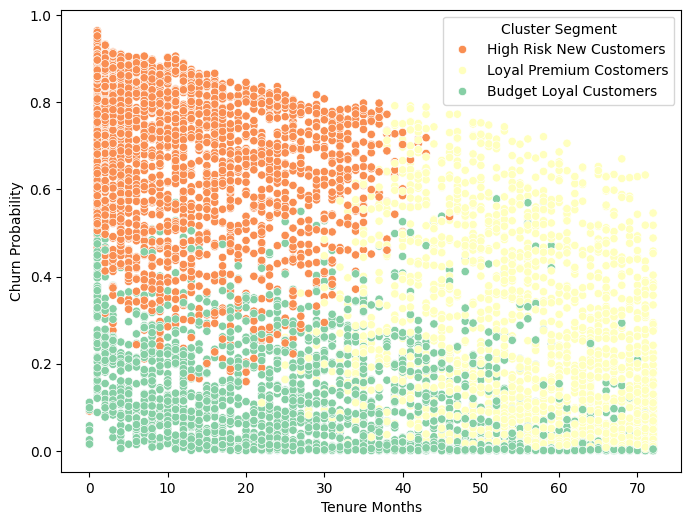

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months', y='Churn Probability',hue='Cluster Segment', data=segmentation_data, palette='Spectral')


<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

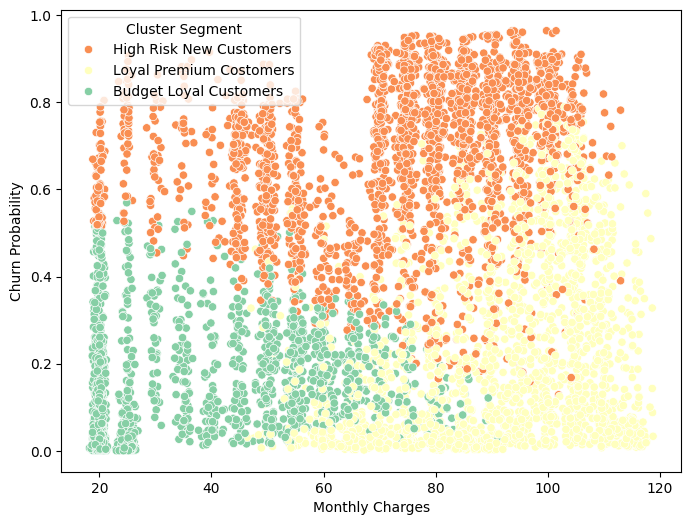

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability',hue='Cluster Segment', data=segmentation_data, palette='Spectral')


<Axes: xlabel='Total Charges', ylabel='Churn Probability'>

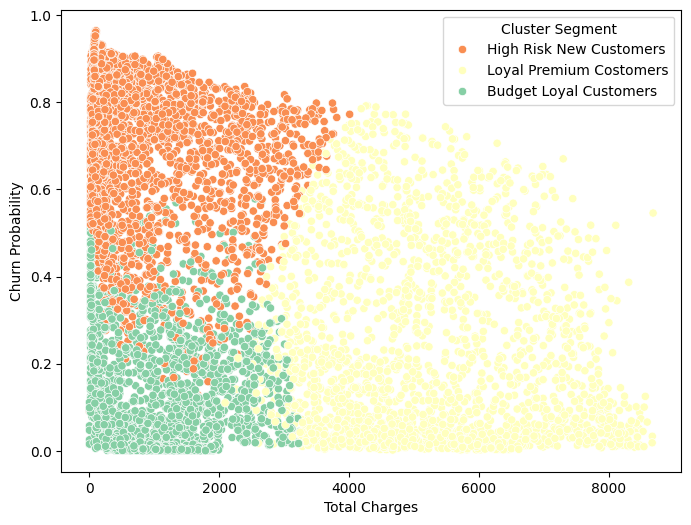

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges', y='Churn Probability',hue='Cluster Segment', data=segmentation_data, palette='Spectral')
